# Southern Indiana Housing and Public School Analysis 
## Part 1

This project analyzes housing sales data from multiple resources (Redfin and Realtor.com Data Centers) along with the results of the ILEARN standardized test for school corporations in Clark and Floyd counties located in Southern Indian. The goal of this project is to anticipate housing prices within the better school districts within those counties in anticipation of a potential move for my family.



In [251]:
#Import necessary libraries and such for project. And some extra stuff, just in case.
import pandas as pd
import matplotlib
from pandas import DataFrame
import matplotlib.pyplot as plt
import numpy as np
import datetime



Now I will read in data I sourced from Redfin's Data Center - it includes data for all of the United State

#### Housing Data by County for the state of Indiana

In [252]:
# Reading in the mother file with all housing data by county

housing_data= pd.read_csv('Data_Sources\county_market_tracker_clean.zip')
housing_data.head()

,period_begin,period_end,table_id,region,state,state_code,property_type,property_type_id,median_sale_price,median_list_price,median_ppsf,median_ppsf_yoy,median_list_ppsf,median_list_ppsf_yoy,inventory,inventory_yoy,sold_above_list,parent_metro_region,parent_metro_region_metro_code,last_updated
0,4/1/2015,4/30/2015,2550,"Bradley County, TN",Tennessee,TN,Condo/Co-op,3,199900.0,NaN,137.957212,NaN,NaN,NaN,3.0,NaN,0.000000,"Cleveland, TN",17420.0,2/10/2025 14:21
1,2/1/2014,2/28/2014,1958,"Dutchess County, NY",New York,NY,Townhouse,13,190250.0,269500.0,133.055161,-0.017109,127.048023,0.062799,21.0,-0.125000,0.000000,"Poughkeepsie, NY",39100.0,2/10/2025 14:21
2,6/1/2023,6/30/2023,1643,"Holt County, MO",Missouri,MO,Single Family Residential,6,75500.0,229500.0,40.810811,-0.724764,120.578231,0.525863,13.0,1.166667,0.000000,Missouri nonmetropolitan area,NaN,2/10/2025 14:21
3,3/1/2015,3/31/2015,1518,"Adams County, MS",Mississippi,MS,All Residential,-1,94900.0,160750.0,70.059310,-0.224828,81.662621,0.217752,57.0,-0.123077,0.181818,"Natchez, MS",35020.0,2/10/2025 14:21
4,2/1/2016,2/29/2016,806,"Washington County, IL",Illinois,IL,Single Family Residential,6,49000.0,76500.0,32.236842,-0.121009,67.222597,-0.260068,57.0,0.212766,0.400000,Illinois nonmetropolitan area,NaN,2/10/2025 14:21


I can see from looking at the first five rows that the dataset I found has housing data from across the United States going back at leas 11 years. That's more than I need, but I want to get a better idea of what the whole dataframe looks like. Let me see the shape and datatypes I'll be working with. 

In [253]:
# What are the columns? I thought I saw pricing per sqft. I need to list all the column names.
# Displaying the size and data types of our data
hdata_shape = housing_data.shape
print(f'The DataFrame has {hdata_shape[0]} rows and {hdata_shape[1]} columns! \n')
print(housing_data.info(20)) 

The DataFrame has 1048575 rows and 20 columns! 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 20 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   period_begin                    1048575 non-null  object 
 1   period_end                      1048575 non-null  object 
 2   table_id                        1048575 non-null  int64  
 3   region                          1048575 non-null  object 
 4   state                           1048575 non-null  object 
 5   state_code                      1048575 non-null  object 
 6   property_type                   1048575 non-null  object 
 7   property_type_id                1048575 non-null  int64  
 8   median_sale_price               1047819 non-null  float64
 9   median_list_price               963668 non-null   float64
 10  median_ppsf                     1037705 non-null  float64
 11  median_ppsf_yo

I'm not interested in year over year data because, for this project, I'm not interested in how the pricing is trending in those counties. I just want a recent snapshot. I'll also have to control for property type since we're only interested in purchasing a single family home. The columns I'll keep are: period_begin, period_end, region (this is the county in this data), state, property_type, median_sale_price, and median_ppsf. 

In [254]:
# drop columns now that I know which columns I want
housing_data_clean = housing_data[['period_begin', 'period_end', 'region', 'state','property_type', 'median_sale_price', 'median_list_price', 'median_ppsf']]
housing_data_clean


,period_begin,period_end,region,state,property_type,median_sale_price,median_list_price,median_ppsf
0,4/1/2015,4/30/2015,"Bradley County, TN",Tennessee,Condo/Co-op,199900.0,NaN,137.957212
1,2/1/2014,2/28/2014,"Dutchess County, NY",New York,Townhouse,190250.0,269500.0,133.055161
2,6/1/2023,6/30/2023,"Holt County, MO",Missouri,Single Family Residential,75500.0,229500.0,40.810811
3,3/1/2015,3/31/2015,"Adams County, MS",Mississippi,All Residential,94900.0,160750.0,70.059310
4,2/1/2016,2/29/2016,"Washington County, IL",Illinois,Single Family Residential,49000.0,76500.0,32.236842
...,...,...,...,...,...,...,...,...
1048570,2/1/2015,2/28/2015,"Apache County, AZ",Arizona,Single Family Residential,151000.0,NaN,91.972077
1048571,1/1/2021,1/31/2021,"Forsyth County, NC",North Carolina,All Residential,209000.0,225000.0,116.748840
1048572,6/1/2022,6/30/2022,"Boone County, WV",West Virginia,Condo/Co-op,35000.0,NaN,7.000000
1048573,4/1/2021,4/30/2021,"Livingston Parish, LA",Louisiana,All Residential,212000.0,219900.0,106.772422


In [255]:
#clean the merged data by narrowing down property types
cleaned_cf = housing_data_clean.loc[housing_data_clean["property_type"] == "Single Family Residential"]

#display the df to verify the correct rows have been removed
display(cleaned_cf)

,period_begin,period_end,region,state,property_type,median_sale_price,median_list_price,median_ppsf
2,6/1/2023,6/30/2023,"Holt County, MO",Missouri,Single Family Residential,75500.0,229500.0,40.810811
4,2/1/2016,2/29/2016,"Washington County, IL",Illinois,Single Family Residential,49000.0,76500.0,32.236842
16,1/1/2023,1/31/2023,"Plymouth County, IA",Iowa,Single Family Residential,230000.0,319750.0,114.113650
17,1/1/2025,1/31/2025,"Hendricks County, IN",Indiana,Single Family Residential,330000.0,347450.0,152.453591
22,5/1/2024,5/31/2024,"Madison County, FL",Florida,Single Family Residential,256600.0,266450.0,170.274970
...,...,...,...,...,...,...,...,...
1048558,5/1/2012,5/31/2012,"McLean County, IL",Illinois,Single Family Residential,72650.0,114900.0,44.549816
1048560,1/1/2013,1/31/2013,"Northampton County, NC",North Carolina,Single Family Residential,22500.0,49900.0,15.000000
1048561,8/1/2021,8/31/2021,"Hickman County, TN",Tennessee,Single Family Residential,205000.0,259900.0,138.714514
1048566,10/1/2019,10/31/2019,"Fayette County, KY",Kentucky,Single Family Residential,223500.0,219500.0,117.670131


Next I'll remove all the rows that do not have Indiana as a state by focusing on specific counties in Indiana that I want to analyze. I'll put these into three separate dataframes and then merge them.

In [256]:
#removes rows that do not contai

housing_data_clark = cleaned_cf.loc[cleaned_cf["region"] == "Clark County, IN"]
housing_data_floyd = cleaned_cf.loc[cleaned_cf["region"]== "Floyd County, IN"]

display(housing_data_clark, housing_data_floyd)

,period_begin,period_end,region,state,property_type,median_sale_price,median_list_price,median_ppsf
1796,12/1/2014,12/31/2014,"Clark County, IN",Indiana,Single Family Residential,129400.0,139950.0,80.013918
22387,12/1/2013,12/31/2013,"Clark County, IN",Indiana,Single Family Residential,122000.0,124900.0,79.416283
27627,5/1/2013,5/31/2013,"Clark County, IN",Indiana,Single Family Residential,112000.0,123900.0,73.339400
27672,5/1/2016,5/31/2016,"Clark County, IN",Indiana,Single Family Residential,135900.0,139900.0,82.405345
38531,10/1/2017,10/31/2017,"Clark County, IN",Indiana,Single Family Residential,160784.0,150000.0,93.334844
...,...,...,...,...,...,...,...,...
1024781,12/1/2016,12/31/2016,"Clark County, IN",Indiana,Single Family Residential,138500.0,139900.0,90.804355
1029177,9/1/2023,9/30/2023,"Clark County, IN",Indiana,Single Family Residential,246900.0,250000.0,156.583037
1035975,2/1/2022,2/28/2022,"Clark County, IN",Indiana,Single Family Residential,224000.0,239950.0,148.619957
1036652,11/1/2024,11/30/2024,"Clark County, IN",Indiana,Single Family Residential,260000.0,244900.0,171.232980


,period_begin,period_end,region,state,property_type,median_sale_price,median_list_price,median_ppsf
24,1/1/2014,1/31/2014,"Floyd County, IN",Indiana,Single Family Residential,108500.0,139900.0,58.016878
18401,10/1/2012,10/31/2012,"Floyd County, IN",Indiana,Single Family Residential,140450.0,123900.0,71.110239
18419,3/1/2014,3/31/2014,"Floyd County, IN",Indiana,Single Family Residential,114000.0,139900.0,72.264351
56998,8/1/2013,8/31/2013,"Floyd County, IN",Indiana,Single Family Residential,130125.0,159900.0,73.380902
57840,8/1/2021,8/31/2021,"Floyd County, IN",Indiana,Single Family Residential,224900.0,210000.0,124.304322
...,...,...,...,...,...,...,...,...
982168,3/1/2013,3/31/2013,"Floyd County, IN",Indiana,Single Family Residential,115000.0,149900.0,69.544365
988376,2/1/2024,2/29/2024,"Floyd County, IN",Indiana,Single Family Residential,275000.0,302400.0,148.026316
996063,7/1/2021,7/31/2021,"Floyd County, IN",Indiana,Single Family Residential,247500.0,215000.0,124.674620
1017426,3/1/2012,3/31/2012,"Floyd County, IN",Indiana,Single Family Residential,116500.0,123375.0,61.635220


In [257]:
#join the two dataframes back together
clark_floyd = housing_data_clark.merge(housing_data_floyd, how = 'outer')
clark_floyd

#drop any rows with NaN values
clark_floyd = clark_floyd.dropna()

# Remove State Column - that information is included in the Region column
clark_floyd = clark_floyd.drop(columns=['state'])

#make a copy of the data
clark_floyd.copy()

,period_begin,period_end,region,property_type,median_sale_price,median_list_price,median_ppsf
0,1/1/2012,1/31/2012,"Clark County, IN",Single Family Residential,121750.0,141400.0,65.195190
1,1/1/2012,1/31/2012,"Floyd County, IN",Single Family Residential,140000.0,114950.0,69.771352
2,1/1/2013,1/31/2013,"Clark County, IN",Single Family Residential,116000.0,120000.0,76.371585
3,1/1/2013,1/31/2013,"Floyd County, IN",Single Family Residential,87500.0,162400.0,66.601837
4,1/1/2014,1/31/2014,"Clark County, IN",Single Family Residential,127950.0,136900.0,73.727365
...,...,...,...,...,...,...,...
271,9/1/2022,9/30/2022,"Floyd County, IN",Single Family Residential,225000.0,234900.0,139.863548
272,9/1/2023,9/30/2023,"Clark County, IN",Single Family Residential,246900.0,250000.0,156.583037
273,9/1/2023,9/30/2023,"Floyd County, IN",Single Family Residential,289000.0,279950.0,151.166514
274,9/1/2024,9/30/2024,"Clark County, IN",Single Family Residential,249900.0,260000.0,164.021164


In [258]:
#checking for any NaN values in the median sales column
check_nan_sale = clark_floyd['median_sale_price'].isnull().values.any()

print(check_nan_sale)

False


In [259]:
# checking for any NaN values in the median list price
check_nan_ppsf= clark_floyd['median_list_price'].isnull().values.any()

#print the results
print(check_nan_ppsf)

False


In [260]:
# checking for any NaN values in the price per square foot
check_nan_list= clark_floyd['median_ppsf'].isnull().values.any()

#print the results
print(check_nan_list)

False


There are no NaN values in this selection of data. All of the data needed to perform my analysis has been selected. Next, column headers will be cleaned and reformatted. 

In [261]:
"""
Cleans and processes the Clark Floyd County Housing DataFrame.

    This function performs the following operations on the input DataFrame:
    1. Cleans column names (capitalizes and removes underscores).

    Parameters:
        clark_floyd (pandas.DataFrame): The input housing dataset.

    Returns:
        pandas.DataFrame: The cleaned and processed DataFrame.

    Example:
        >>> clean_kick_starter = clean_ks(clark_floyd)\"
"""
# function       
def clean_hd (clark_floyd) -> pd.DataFrame:

    # Clean column names
    clark_floyd.columns =  clark_floyd.columns.str.title()
    clark_floyd.columns =  clark_floyd.columns.str.strip().str.replace('_', ' ')

    return clark_floyd

final_cf = clean_hd(clark_floyd)

display(final_cf)


,Period Begin,Period End,Region,Property Type,Median Sale Price,Median List Price,Median Ppsf
0,1/1/2012,1/31/2012,"Clark County, IN",Single Family Residential,121750.0,141400.0,65.195190
1,1/1/2012,1/31/2012,"Floyd County, IN",Single Family Residential,140000.0,114950.0,69.771352
2,1/1/2013,1/31/2013,"Clark County, IN",Single Family Residential,116000.0,120000.0,76.371585
3,1/1/2013,1/31/2013,"Floyd County, IN",Single Family Residential,87500.0,162400.0,66.601837
4,1/1/2014,1/31/2014,"Clark County, IN",Single Family Residential,127950.0,136900.0,73.727365
...,...,...,...,...,...,...,...
271,9/1/2022,9/30/2022,"Floyd County, IN",Single Family Residential,225000.0,234900.0,139.863548
272,9/1/2023,9/30/2023,"Clark County, IN",Single Family Residential,246900.0,250000.0,156.583037
273,9/1/2023,9/30/2023,"Floyd County, IN",Single Family Residential,289000.0,279950.0,151.166514
274,9/1/2024,9/30/2024,"Clark County, IN",Single Family Residential,249900.0,260000.0,164.021164


There's sales data going all the way back to 2012. I am not analyzing pricing trends for the area, I only need an accurate snapshot for current housing prices. Data from February 2024 to January 2025 will be pulled; first, I will verify the datatypes for each column.

In [262]:
#checking datatypes before I move on 
final_cf.dtypes

Period Begin          object
Period End            object
Region                object
Property Type         object
Median Sale Price    float64
Median List Price    float64
Median Ppsf          float64
dtype: object

Since Period Begin and Period End are objects, I will need to change them to datetime datatypes so the computer will recognize them as timestamps. 

In [263]:
#making a copy to avoid the SettingwithCopyWarning
final_cfcopy = final_cf.copy()

#change to datetime
final_cfcopy['Period Begin'] = pd.to_datetime(final_cfcopy['Period Begin'], format='%m/%d/%Y')

#adjust Period End to datetime 
final_cfcopy['Period End'] = pd.to_datetime(final_cfcopy['Period End'], format='%m/%d/%Y')

#display final result to verify the dates have been changed to datetime 
final_cfcopy


,Period Begin,Period End,Region,Property Type,Median Sale Price,Median List Price,Median Ppsf
0,2012-01-01,2012-01-31,"Clark County, IN",Single Family Residential,121750.0,141400.0,65.195190
1,2012-01-01,2012-01-31,"Floyd County, IN",Single Family Residential,140000.0,114950.0,69.771352
2,2013-01-01,2013-01-31,"Clark County, IN",Single Family Residential,116000.0,120000.0,76.371585
3,2013-01-01,2013-01-31,"Floyd County, IN",Single Family Residential,87500.0,162400.0,66.601837
4,2014-01-01,2014-01-31,"Clark County, IN",Single Family Residential,127950.0,136900.0,73.727365
...,...,...,...,...,...,...,...
271,2022-09-01,2022-09-30,"Floyd County, IN",Single Family Residential,225000.0,234900.0,139.863548
272,2023-09-01,2023-09-30,"Clark County, IN",Single Family Residential,246900.0,250000.0,156.583037
273,2023-09-01,2023-09-30,"Floyd County, IN",Single Family Residential,289000.0,279950.0,151.166514
274,2024-09-01,2024-09-30,"Clark County, IN",Single Family Residential,249900.0,260000.0,164.021164


Removing any data that's dated prior to February 2024.

In [264]:
# Filter for the last rolling 13 months (anything after February 1, 2024)
filtered_cf = final_cfcopy.loc[(final_cfcopy['Period Begin'] >= '2024-02-01')]   

filtered_cf

,Period Begin,Period End,Region,Property Type,Median Sale Price,Median List Price,Median Ppsf
22,2025-01-01,2025-01-31,"Clark County, IN",Single Family Residential,250000.0,274900.0,145.509943
23,2025-01-01,2025-01-31,"Floyd County, IN",Single Family Residential,253900.0,290000.0,137.500000
46,2024-10-01,2024-10-31,"Floyd County, IN",Single Family Residential,235000.0,274900.0,155.259823
66,2024-11-01,2024-11-30,"Clark County, IN",Single Family Residential,260000.0,244900.0,171.232980
67,2024-11-01,2024-11-30,"Floyd County, IN",Single Family Residential,286500.0,269000.0,154.476351
91,2024-12-01,2024-12-31,"Clark County, IN",Single Family Residential,234945.0,262990.0,155.327776
92,2024-12-01,2024-12-31,"Floyd County, IN",Single Family Residential,301750.0,252450.0,148.990538
114,2024-02-01,2024-02-29,"Clark County, IN",Single Family Residential,252000.0,248500.0,160.736976
115,2024-02-01,2024-02-29,"Floyd County, IN",Single Family Residential,275000.0,302400.0,148.026316
137,2024-03-01,2024-03-31,"Clark County, IN",Single Family Residential,250000.0,263500.0,165.925455


I'd also like to see the average median sale price for the selected time period along with the average price per square foot of houses sold.

In [265]:
#find average sale price for each county for past 12 months
average_saleprice = filtered_cf.groupby('Region')['Median Sale Price'].mean()
average_saleprice = pd.DataFrame(average_saleprice)
display(average_saleprice)

,Median Sale Price
Region,
"Clark County, IN",255938.5
"Floyd County, IN",278450.0


In [266]:
#find average sale price for each county for past 12 months
average_ppsf = filtered_cf.groupby('Region')['Median Ppsf'].mean()
average_ppsf = pd.DataFrame(average_ppsf)
display(average_ppsf)

,Median Ppsf
Region,
"Clark County, IN",163.120663
"Floyd County, IN",151.948779


## Part 2: 2024 ILEARN Grade 3-8 Corporation Results(for Indiana)

 In this part I will clean the data pulled from [2024 ILEARN Grade 3-8 Corporation Results (for Indiana) ](https://www.in.gov/doe/it/data-center-and-reports/). This scores the proficiency of the students in several core subjects (English Language Arts (ELA), Math, Science, and Social Studies) for all school corporations (districts) in Indiana. 

In [267]:
# read in the data for ILEARN 2024 test scores for all school coporations in Indiana - ELA section
ilearn_ELA_corp = pd.read_csv('Data_Sources\ILEARN_Corp_ELA.csv')

In [268]:
# verify data reads in and print the first five rows)
ilearn_ELA_corp.head()

,Data Notes:,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51
0,Scores reflect all ILEARN Spring 2024 testers,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,*** - Indicates less than 10 students in group...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,Grade 3,NaN,NaN,NaN,NaN,NaN,NaN,Grade 4,...,NaN,NaN,Corporation Total,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Corp ID,Corp Name,ELA\nBelow\nProficiency,ELA \nApproaching\nProficiency,ELA \nAt\nProficiency,ELA \nAbove\nProficiency,ELA\nTotal\nProficient,ELA\nTotal\nTested,ELA\nProficient \n%,ELA\nBelow\nProficiency,...,ELA\nTotal\nTested,ELA\nProficient \n%,ELA\nBelow\nProficiency,ELA \nApproaching\nProficiency,ELA \nAt\nProficiency,ELA \nAbove\nProficiency,ELA\nTotal\nProficient,ELA\nTotal\nTested,ELA\nProficient \n%,NaN
4,0015,Adams Central Community Schools,35,21,24,9,33,89,37.1%,27,...,99,53.5%,168,139,180,108,288,595,48.4%,NaN


Top two rows are notes regarding the whole dataset and their removal should not affect my analysis. I'm going to remove those columns by first replacing them with 1, then removing the rows that have a "1" in column "Unnamed: 1". Since this column has only string values (the names of the different corporations) it should not remove any viable data. 

In [269]:
# will replace Nan value in dataframe with value 1
ela_copy = ilearn_ELA_corp.replace(to_replace = np.nan, value = 1)

for x in ela_copy.index:
    if ela_copy.loc[x, "Unnamed: 1"] == 1:
        ela_copy.drop(x, inplace=True)
ela_copy

,Data Notes:,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51
3,Corp ID,Corp Name,ELA\nBelow\nProficiency,ELA \nApproaching\nProficiency,ELA \nAt\nProficiency,ELA \nAbove\nProficiency,ELA\nTotal\nProficient,ELA\nTotal\nTested,ELA\nProficient \n%,ELA\nBelow\nProficiency,...,ELA\nTotal\nTested,ELA\nProficient \n%,ELA\nBelow\nProficiency,ELA \nApproaching\nProficiency,ELA \nAt\nProficiency,ELA \nAbove\nProficiency,ELA\nTotal\nProficient,ELA\nTotal\nTested,ELA\nProficient \n%,1.0
4,0015,Adams Central Community Schools,35,21,24,9,33,89,37.1%,27,...,99,53.5%,168,139,180,108,288,595,48.4%,1.0
5,0025,North Adams Community Schools,51,25,22,2,24,100,24.0%,31,...,98,44.9%,186,150,143,68,211,547,38.6%,1.0
6,0035,South Adams Schools,29,30,23,8,31,90,34.4%,29,...,88,54.5%,176,161,142,83,225,562,40.0%,1.0
7,0125,MSD Southwest Allen County Schls,135,110,157,144,301,546,55.1%,128,...,613,49.8%,803,833,1051,793,1844,3480,53.0%,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
389,9970,ACE Preparatory Academy,10,4,2,0,2,16,12.5%,8,...,1,1,27,15,11,2,13,55,23.6%,1.0
390,9975,Global Preparatory Academy,62,18,13,5,18,98,18.4%,26,...,37,16.2%,220,79,51,24,75,374,20.1%,1.0
391,9980,Steel City Academy,20,1,2,0,2,23,8.7%,17,...,23,34.8%,92,25,15,3,18,135,13.3%,1.0
392,9985,Seven Oaks Classical School,5,15,20,12,32,52,61.5%,3,...,26,65.4%,25,65,85,66,151,241,62.7%,1.0


I will verify the datatypes for each column.

In [270]:
#find out datatype for Column 'Unnamed: 1'
print(ela_copy.dtypes)

Data Notes:     object
Unnamed: 1      object
Unnamed: 2      object
Unnamed: 3      object
Unnamed: 4      object
Unnamed: 5      object
Unnamed: 6      object
Unnamed: 7      object
Unnamed: 8      object
Unnamed: 9      object
Unnamed: 10     object
Unnamed: 11     object
Unnamed: 12     object
Unnamed: 13     object
Unnamed: 14     object
Unnamed: 15     object
Unnamed: 16     object
Unnamed: 17     object
Unnamed: 18     object
Unnamed: 19     object
Unnamed: 20     object
Unnamed: 21     object
Unnamed: 22     object
Unnamed: 23     object
Unnamed: 24     object
Unnamed: 25     object
Unnamed: 26     object
Unnamed: 27     object
Unnamed: 28     object
Unnamed: 29     object
Unnamed: 30     object
Unnamed: 31     object
Unnamed: 32     object
Unnamed: 33     object
Unnamed: 34     object
Unnamed: 35     object
Unnamed: 36     object
Unnamed: 37     object
Unnamed: 38     object
Unnamed: 39     object
Unnamed: 40     object
Unnamed: 41     object
Unnamed: 42     object
Unnamed: 43

I will now rename the "Unnamed" columns with the true column headers buried in the first row.

In [271]:
# Renaming columns
ela_copy.rename(columns={'Data Notes:': 'Corp ID', 
                         'Unnamed: 1': 'Corp Name', 
                         'Unnamed: 2': 'ELA Below Proficiency', 
                         'Unnamed: 3': 'ELA Approaching Proficiency', 
                         'Unnamed: 4': 'ELA At Proficiency',
                         'Unnamed: 5': 'ELA Above Proficiency',
                         'Unnamed: 6': 'ELA Total Proficient',
                         'Unnamed: 7': 'ELA Total Tested',
                         'Unnamed: 8': 'ELA Proficient %',
                         }
                         , inplace=True)
display(ela_copy)

,Corp ID,Corp Name,ELA Below Proficiency,ELA Approaching Proficiency,ELA At Proficiency,ELA Above Proficiency,ELA Total Proficient,ELA Total Tested,ELA Proficient %,Unnamed: 9,...,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51
3,Corp ID,Corp Name,ELA\nBelow\nProficiency,ELA \nApproaching\nProficiency,ELA \nAt\nProficiency,ELA \nAbove\nProficiency,ELA\nTotal\nProficient,ELA\nTotal\nTested,ELA\nProficient \n%,ELA\nBelow\nProficiency,...,ELA\nTotal\nTested,ELA\nProficient \n%,ELA\nBelow\nProficiency,ELA \nApproaching\nProficiency,ELA \nAt\nProficiency,ELA \nAbove\nProficiency,ELA\nTotal\nProficient,ELA\nTotal\nTested,ELA\nProficient \n%,1.0
4,0015,Adams Central Community Schools,35,21,24,9,33,89,37.1%,27,...,99,53.5%,168,139,180,108,288,595,48.4%,1.0
5,0025,North Adams Community Schools,51,25,22,2,24,100,24.0%,31,...,98,44.9%,186,150,143,68,211,547,38.6%,1.0
6,0035,South Adams Schools,29,30,23,8,31,90,34.4%,29,...,88,54.5%,176,161,142,83,225,562,40.0%,1.0
7,0125,MSD Southwest Allen County Schls,135,110,157,144,301,546,55.1%,128,...,613,49.8%,803,833,1051,793,1844,3480,53.0%,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
389,9970,ACE Preparatory Academy,10,4,2,0,2,16,12.5%,8,...,1,1,27,15,11,2,13,55,23.6%,1.0
390,9975,Global Preparatory Academy,62,18,13,5,18,98,18.4%,26,...,37,16.2%,220,79,51,24,75,374,20.1%,1.0
391,9980,Steel City Academy,20,1,2,0,2,23,8.7%,17,...,23,34.8%,92,25,15,3,18,135,13.3%,1.0
392,9985,Seven Oaks Classical School,5,15,20,12,32,52,61.5%,3,...,26,65.4%,25,65,85,66,151,241,62.7%,1.0


I will be dropping all columns after column 8 since those deal with higher grades. For simplicity's sake I'm going to only focus on Grade 3 grades for now. I know that the additional columns include the scores for higher grades from viewing the data as a .CSV before reading it into the notebook.

In [272]:
#drop rows 10 - 52 as I only want to focus on Grade 3 scores 
ela_copy2 = ela_copy.drop(ela_copy.iloc[:, 9:52], axis=1)

In [273]:
#dropping rows that aren't the final proficient %
ela_copy3 = ela_copy2.drop(labels=None, 
                            axis=1, 
                            columns=['ELA Below Proficiency', 
                                    'ELA Approaching Proficiency', 
                                    'ELA At Proficiency', 
                                    'ELA Above Proficiency',
                                    'ELA Total Proficient',
                                    'ELA Total Tested'], 
                            level=None, 
                            inplace=False, 
                            errors='raise'
                            )

#display the df to confirm the code is working the way I want
ela_copy3


,Corp ID,Corp Name,ELA Proficient %
3,Corp ID,Corp Name,ELA\nProficient \n%
4,0015,Adams Central Community Schools,37.1%
5,0025,North Adams Community Schools,24.0%
6,0035,South Adams Schools,34.4%
7,0125,MSD Southwest Allen County Schls,55.1%
...,...,...,...
389,9970,ACE Preparatory Academy,12.5%
390,9975,Global Preparatory Academy,18.4%
391,9980,Steel City Academy,8.7%
392,9985,Seven Oaks Classical School,61.5%


Now I need to remove any school districts that aren't in Floyd and Clark counties. I will filter out the unwanted school corporations using the state corporation ID assigned to each corporation that is included in the dataframe.

In [274]:
# List of school corporation state IDs
corps = ['1000', '1010', '0935', '0945', '2400']

# Filter DataFrame by list of school corporation state IDs
ela_copy3= ela_copy3[ela_copy3['Corp ID'].isin(corps)]
display(ela_copy3)

,Corp ID,Corp Name,ELA Proficient %
24,0935,Borden-Henryville School Corporation,30.9%
25,0945,Silver Creek School Corporation,41.7%
26,1000,Clarksville Community School Corp,13.7%
27,1010,Greater Clark County Schools,35.3%
64,2400,New Albany-Floyd Co Con Sch,55.8%


I will now repeat those steps for the remaining subjects: math, science, and social studies. 

In [275]:
#read in the data for ILEARN 2024 test scores for all school coporations in Indiana - Math section

ilearn_Math_corp = pd.read_csv('Data_Sources\ILEARN_Corp_Math.csv')


In [276]:
# will replace Nan value in dataframe with value 1
math_copy = ilearn_Math_corp.replace(to_replace = np.nan, value = 1)

#display df to confirm 
math_copy

,Data Notes:,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51
0,Scores reflect all ILEARN Spring 2024 testers,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1.0
1,*** - Indicates less than 10 students in group...,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1.0
2,1,1,Grade 3,1,1,1,1,1,1,Grade 4,...,1,1,Corporation Total,1,1,1,1,1,1,1.0
3,Corp ID,Corp Name,Math\nBelow\nProficiency,Math \nApproaching\nProficiency,Math \nAt\nProficiency,Math \nAbove\nProficiency,Math\nTotal\nProficient,Math\nTotal\nTested,Math\nProficient \n%,Math\nBelow\nProficiency,...,Math\nTotal\nTested,Math\nProficient \n%,Math\nBelow\nProficiency,Math \nApproaching\nProficiency,Math \nAt\nProficiency,Math \nAbove\nProficiency,Math\nTotal\nProficient,Math\nTotal\nTested,Math\nProficient \n%,1.0
4,0015,Adams Central Community Schools,16,17,39,17,56,89,62.9%,20,...,99,70.7%,107,124,191,173,364,595,61.2%,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
389,9970,ACE Preparatory Academy,7,7,2,0,2,16,12.5%,7,...,1,1,22,18,12,3,15,55,27.3%,1.0
390,9975,Global Preparatory Academy,54,22,16,6,22,98,22.4%,28,...,37,8.1%,258,60,43,13,56,374,15.0%,1.0
391,9980,Steel City Academy,20,2,1,0,1,23,4.3%,19,...,23,17.4%,107,19,8,1,9,135,6.7%,1.0
392,9985,Seven Oaks Classical School,2,5,17,28,45,52,86.5%,0,...,26,50.0%,19,56,68,98,166,241,68.9%,1.0


In [277]:
#change rows with NaN values to 1, drop from dataframe
for x in math_copy.index:
    if math_copy.loc[x, "Unnamed: 1"] == 1:
        math_copy.drop(x, inplace=True)
# display results to verify 
math_copy

,Data Notes:,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51
3,Corp ID,Corp Name,Math\nBelow\nProficiency,Math \nApproaching\nProficiency,Math \nAt\nProficiency,Math \nAbove\nProficiency,Math\nTotal\nProficient,Math\nTotal\nTested,Math\nProficient \n%,Math\nBelow\nProficiency,...,Math\nTotal\nTested,Math\nProficient \n%,Math\nBelow\nProficiency,Math \nApproaching\nProficiency,Math \nAt\nProficiency,Math \nAbove\nProficiency,Math\nTotal\nProficient,Math\nTotal\nTested,Math\nProficient \n%,1.0
4,0015,Adams Central Community Schools,16,17,39,17,56,89,62.9%,20,...,99,70.7%,107,124,191,173,364,595,61.2%,1.0
5,0025,North Adams Community Schools,28,27,32,13,45,100,45.0%,35,...,98,33.7%,205,155,133,52,185,545,33.9%,1.0
6,0035,South Adams Schools,20,16,32,22,54,90,60.0%,18,...,88,58.0%,126,143,161,132,293,562,52.1%,1.0
7,0125,MSD Southwest Allen County Schls,91,97,160,198,358,546,65.6%,116,...,612,47.4%,819,820,969,871,1840,3479,52.9%,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
389,9970,ACE Preparatory Academy,7,7,2,0,2,16,12.5%,7,...,1,1,22,18,12,3,15,55,27.3%,1.0
390,9975,Global Preparatory Academy,54,22,16,6,22,98,22.4%,28,...,37,8.1%,258,60,43,13,56,374,15.0%,1.0
391,9980,Steel City Academy,20,2,1,0,1,23,4.3%,19,...,23,17.4%,107,19,8,1,9,135,6.7%,1.0
392,9985,Seven Oaks Classical School,2,5,17,28,45,52,86.5%,0,...,26,50.0%,19,56,68,98,166,241,68.9%,1.0


In [278]:
# Renaming column headers
math_copy.rename(columns={'Data Notes:': 'Corp ID', 
                         'Unnamed: 1': 'Corp Name', 
                         'Unnamed: 2': 'Math Below Proficiency', 
                         'Unnamed: 3': 'Math Approaching Proficiency', 
                         'Unnamed: 4': 'Math At Proficiency',
                         'Unnamed: 5': 'Math Above Proficiency',
                         'Unnamed: 6': 'Math Total Proficient',
                         'Unnamed: 7': 'Math Total Tested',
                         'Unnamed: 8': 'Math Proficient %',
                         }
                         , inplace=True)
display(math_copy)

,Corp ID,Corp Name,Math Below Proficiency,Math Approaching Proficiency,Math At Proficiency,Math Above Proficiency,Math Total Proficient,Math Total Tested,Math Proficient %,Unnamed: 9,...,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51
3,Corp ID,Corp Name,Math\nBelow\nProficiency,Math \nApproaching\nProficiency,Math \nAt\nProficiency,Math \nAbove\nProficiency,Math\nTotal\nProficient,Math\nTotal\nTested,Math\nProficient \n%,Math\nBelow\nProficiency,...,Math\nTotal\nTested,Math\nProficient \n%,Math\nBelow\nProficiency,Math \nApproaching\nProficiency,Math \nAt\nProficiency,Math \nAbove\nProficiency,Math\nTotal\nProficient,Math\nTotal\nTested,Math\nProficient \n%,1.0
4,0015,Adams Central Community Schools,16,17,39,17,56,89,62.9%,20,...,99,70.7%,107,124,191,173,364,595,61.2%,1.0
5,0025,North Adams Community Schools,28,27,32,13,45,100,45.0%,35,...,98,33.7%,205,155,133,52,185,545,33.9%,1.0
6,0035,South Adams Schools,20,16,32,22,54,90,60.0%,18,...,88,58.0%,126,143,161,132,293,562,52.1%,1.0
7,0125,MSD Southwest Allen County Schls,91,97,160,198,358,546,65.6%,116,...,612,47.4%,819,820,969,871,1840,3479,52.9%,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
389,9970,ACE Preparatory Academy,7,7,2,0,2,16,12.5%,7,...,1,1,22,18,12,3,15,55,27.3%,1.0
390,9975,Global Preparatory Academy,54,22,16,6,22,98,22.4%,28,...,37,8.1%,258,60,43,13,56,374,15.0%,1.0
391,9980,Steel City Academy,20,2,1,0,1,23,4.3%,19,...,23,17.4%,107,19,8,1,9,135,6.7%,1.0
392,9985,Seven Oaks Classical School,2,5,17,28,45,52,86.5%,0,...,26,50.0%,19,56,68,98,166,241,68.9%,1.0


In [279]:
#drop rows 10 - 52 as I only want to focus on Grade 3 scores 
math_copy2 = math_copy.drop(math_copy.iloc[:, 9:52], axis=1)

#display the results
math_copy2

,Corp ID,Corp Name,Math Below Proficiency,Math Approaching Proficiency,Math At Proficiency,Math Above Proficiency,Math Total Proficient,Math Total Tested,Math Proficient %
3,Corp ID,Corp Name,Math\nBelow\nProficiency,Math \nApproaching\nProficiency,Math \nAt\nProficiency,Math \nAbove\nProficiency,Math\nTotal\nProficient,Math\nTotal\nTested,Math\nProficient \n%
4,0015,Adams Central Community Schools,16,17,39,17,56,89,62.9%
5,0025,North Adams Community Schools,28,27,32,13,45,100,45.0%
6,0035,South Adams Schools,20,16,32,22,54,90,60.0%
7,0125,MSD Southwest Allen County Schls,91,97,160,198,358,546,65.6%
...,...,...,...,...,...,...,...,...,...
389,9970,ACE Preparatory Academy,7,7,2,0,2,16,12.5%
390,9975,Global Preparatory Academy,54,22,16,6,22,98,22.4%
391,9980,Steel City Academy,20,2,1,0,1,23,4.3%
392,9985,Seven Oaks Classical School,2,5,17,28,45,52,86.5%


In [280]:
#dropping first row
math_copy2.drop(index=math_copy.index[0], axis=0, inplace=True)

#display the results
math_copy2

,Corp ID,Corp Name,Math Below Proficiency,Math Approaching Proficiency,Math At Proficiency,Math Above Proficiency,Math Total Proficient,Math Total Tested,Math Proficient %
4,0015,Adams Central Community Schools,16,17,39,17,56,89,62.9%
5,0025,North Adams Community Schools,28,27,32,13,45,100,45.0%
6,0035,South Adams Schools,20,16,32,22,54,90,60.0%
7,0125,MSD Southwest Allen County Schls,91,97,160,198,358,546,65.6%
8,0225,Northwest Allen County Schools,102,103,232,155,387,592,65.4%
...,...,...,...,...,...,...,...,...,...
389,9970,ACE Preparatory Academy,7,7,2,0,2,16,12.5%
390,9975,Global Preparatory Academy,54,22,16,6,22,98,22.4%
391,9980,Steel City Academy,20,2,1,0,1,23,4.3%
392,9985,Seven Oaks Classical School,2,5,17,28,45,52,86.5%


In [281]:
#dropping rows that are the final proficient %
math_copy3 = math_copy2.drop(labels=None, 
                         axis=1, 
                         columns=['Math Below Proficiency', 
                                    'Math Approaching Proficiency', 
                                    'Math At Proficiency', 
                                    'Math Above Proficiency',
                                    'Math Total Proficient',
                                    'Math Total Tested'], 
                        level=None, 
                        inplace=False, 
                        errors='raise')
math_copy3

,Corp ID,Corp Name,Math Proficient %
4,0015,Adams Central Community Schools,62.9%
5,0025,North Adams Community Schools,45.0%
6,0035,South Adams Schools,60.0%
7,0125,MSD Southwest Allen County Schls,65.6%
8,0225,Northwest Allen County Schools,65.4%
...,...,...,...
389,9970,ACE Preparatory Academy,12.5%
390,9975,Global Preparatory Academy,22.4%
391,9980,Steel City Academy,4.3%
392,9985,Seven Oaks Classical School,86.5%


In [282]:
# List of school corporation state IDs
corps = ['1000', '1010', '0935', '0945', '2400']

# Filter DataFrame by list of school corporation state IDs
math_copy3= math_copy3[math_copy3['Corp ID'].isin(corps)]
display(math_copy3)

,Corp ID,Corp Name,Math Proficient %
24,0935,Borden-Henryville School Corporation,49.1%
25,0945,Silver Creek School Corporation,54.8%
26,1000,Clarksville Community School Corp,25.1%
27,1010,Greater Clark County Schools,47.1%
64,2400,New Albany-Floyd Co Con Sch,71.1%


In [283]:
# read in science data
ilearn_Science_corp = pd.read_csv('Data_Sources\ILEARN_Corp_Science.csv')

#display first five rows
ilearn_Science_corp.head(5)

,Data Notes:,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23
0,Scores reflect all ILEARN Spring 2024 testers,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,*** - Indicates less than 10 students in group...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,Grade 4,NaN,NaN,NaN,NaN,NaN,NaN,Grade 6,...,NaN,NaN,Corporation Total,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Corp ID,Corp Name,Science\nBelow\nProficiency,Science \nApproaching\nProficiency,Science \nAt\nProficiency,Science \nAbove\nProficiency,Science\nTotal\nProficient,Science\nTotal\nTested,Science\nProficient \n%,Science\nBelow\nProficiency,...,Science\nTotal\nTested,Science\nProficient \n%,Science\nBelow\nProficiency,Science \nApproaching\nProficiency,Science \nAt\nProficiency,Science \nAbove\nProficiency,Science\nTotal\nProficient,Science\nTotal\nTested,Science\nProficient \n%,NaN
4,0015,Adams Central Community Schools,11,42,37,4,41,94,43.6%,11,...,111,62.2%,22,73,72,38,110,205,53.7%,NaN


In [284]:
# will replace Nan value in dataframe with value 1
sci_copy = ilearn_Science_corp.replace(to_replace = np.nan, value = 1)

# display result
sci_copy 

,Data Notes:,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23
0,Scores reflect all ILEARN Spring 2024 testers,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1.0
1,*** - Indicates less than 10 students in group...,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1.0
2,1,1,Grade 4,1,1,1,1,1,1,Grade 6,...,1,1,Corporation Total,1,1,1,1,1,1,1.0
3,Corp ID,Corp Name,Science\nBelow\nProficiency,Science \nApproaching\nProficiency,Science \nAt\nProficiency,Science \nAbove\nProficiency,Science\nTotal\nProficient,Science\nTotal\nTested,Science\nProficient \n%,Science\nBelow\nProficiency,...,Science\nTotal\nTested,Science\nProficient \n%,Science\nBelow\nProficiency,Science \nApproaching\nProficiency,Science \nAt\nProficiency,Science \nAbove\nProficiency,Science\nTotal\nProficient,Science\nTotal\nTested,Science\nProficient \n%,1.0
4,0015,Adams Central Community Schools,11,42,37,4,41,94,43.6%,11,...,111,62.2%,22,73,72,38,110,205,53.7%,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383,9970,ACE Preparatory Academy,2,7,9,2,11,20,55.0%,1,...,1,1,2,7,9,2,11,20,55.0%,1.0
384,9975,Global Preparatory Academy,18,14,12,2,14,46,30.4%,37,...,70,10.0%,55,40,16,5,21,116,18.1%,1.0
385,9980,Steel City Academy,8,10,4,0,4,22,18.2%,14,...,28,7.1%,22,22,5,1,6,50,12.0%,1.0
386,9985,Seven Oaks Classical School,0,6,21,16,37,43,86.0%,2,...,33,54.5%,2,19,29,26,55,76,72.4%,1.0


In [285]:
# loop through the df and drop any row where Unnamed: 1 column has a value of 1
for x in sci_copy.index:
    if sci_copy.loc[x, "Unnamed: 1"] == 1:
        sci_copy.drop(x, inplace=True)

# display result
sci_copy

,Data Notes:,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23
3,Corp ID,Corp Name,Science\nBelow\nProficiency,Science \nApproaching\nProficiency,Science \nAt\nProficiency,Science \nAbove\nProficiency,Science\nTotal\nProficient,Science\nTotal\nTested,Science\nProficient \n%,Science\nBelow\nProficiency,...,Science\nTotal\nTested,Science\nProficient \n%,Science\nBelow\nProficiency,Science \nApproaching\nProficiency,Science \nAt\nProficiency,Science \nAbove\nProficiency,Science\nTotal\nProficient,Science\nTotal\nTested,Science\nProficient \n%,1.0
4,0015,Adams Central Community Schools,11,42,37,4,41,94,43.6%,11,...,111,62.2%,22,73,72,38,110,205,53.7%,1.0
5,0025,North Adams Community Schools,17,36,28,9,37,90,41.1%,15,...,82,35.4%,32,74,45,21,66,172,38.4%,1.0
6,0035,South Adams Schools,17,48,29,6,35,100,35.0%,18,...,100,45.0%,35,85,54,26,80,200,40.0%,1.0
7,0125,MSD Southwest Allen County Schls,65,178,205,90,295,538,54.8%,40,...,591,59.7%,105,376,345,303,648,1129,57.4%,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383,9970,ACE Preparatory Academy,2,7,9,2,11,20,55.0%,1,...,1,1,2,7,9,2,11,20,55.0%,1.0
384,9975,Global Preparatory Academy,18,14,12,2,14,46,30.4%,37,...,70,10.0%,55,40,16,5,21,116,18.1%,1.0
385,9980,Steel City Academy,8,10,4,0,4,22,18.2%,14,...,28,7.1%,22,22,5,1,6,50,12.0%,1.0
386,9985,Seven Oaks Classical School,0,6,21,16,37,43,86.0%,2,...,33,54.5%,2,19,29,26,55,76,72.4%,1.0


In [286]:
# Rename the columns from Unnamed to make the data more coherent.
sci_copy.rename(columns={'Data Notes:': 'Corp ID', 
                         'Unnamed: 1': 'Corp Name', 
                         'Unnamed: 2': 'Science Below Proficiency', 
                         'Unnamed: 3': 'Science Approaching Proficiency', 
                         'Unnamed: 4': 'Science At Proficiency',
                         'Unnamed: 5': 'Science Above Proficiency',
                         'Unnamed: 6': 'Science Total Proficient',
                         'Unnamed: 7': 'Science Total Tested',
                         'Unnamed: 8': 'Science Proficient %',
                         }
                         , inplace=True)
display(sci_copy)

,Corp ID,Corp Name,Science Below Proficiency,Science Approaching Proficiency,Science At Proficiency,Science Above Proficiency,Science Total Proficient,Science Total Tested,Science Proficient %,Unnamed: 9,...,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23
3,Corp ID,Corp Name,Science\nBelow\nProficiency,Science \nApproaching\nProficiency,Science \nAt\nProficiency,Science \nAbove\nProficiency,Science\nTotal\nProficient,Science\nTotal\nTested,Science\nProficient \n%,Science\nBelow\nProficiency,...,Science\nTotal\nTested,Science\nProficient \n%,Science\nBelow\nProficiency,Science \nApproaching\nProficiency,Science \nAt\nProficiency,Science \nAbove\nProficiency,Science\nTotal\nProficient,Science\nTotal\nTested,Science\nProficient \n%,1.0
4,0015,Adams Central Community Schools,11,42,37,4,41,94,43.6%,11,...,111,62.2%,22,73,72,38,110,205,53.7%,1.0
5,0025,North Adams Community Schools,17,36,28,9,37,90,41.1%,15,...,82,35.4%,32,74,45,21,66,172,38.4%,1.0
6,0035,South Adams Schools,17,48,29,6,35,100,35.0%,18,...,100,45.0%,35,85,54,26,80,200,40.0%,1.0
7,0125,MSD Southwest Allen County Schls,65,178,205,90,295,538,54.8%,40,...,591,59.7%,105,376,345,303,648,1129,57.4%,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383,9970,ACE Preparatory Academy,2,7,9,2,11,20,55.0%,1,...,1,1,2,7,9,2,11,20,55.0%,1.0
384,9975,Global Preparatory Academy,18,14,12,2,14,46,30.4%,37,...,70,10.0%,55,40,16,5,21,116,18.1%,1.0
385,9980,Steel City Academy,8,10,4,0,4,22,18.2%,14,...,28,7.1%,22,22,5,1,6,50,12.0%,1.0
386,9985,Seven Oaks Classical School,0,6,21,16,37,43,86.0%,2,...,33,54.5%,2,19,29,26,55,76,72.4%,1.0


In [287]:
#dropping the columns that aren't for Grade 3
sci_copy = sci_copy.drop(sci_copy.iloc[:, 9:52], axis=1)

# display the result
sci_copy

,Corp ID,Corp Name,Science Below Proficiency,Science Approaching Proficiency,Science At Proficiency,Science Above Proficiency,Science Total Proficient,Science Total Tested,Science Proficient %
3,Corp ID,Corp Name,Science\nBelow\nProficiency,Science \nApproaching\nProficiency,Science \nAt\nProficiency,Science \nAbove\nProficiency,Science\nTotal\nProficient,Science\nTotal\nTested,Science\nProficient \n%
4,0015,Adams Central Community Schools,11,42,37,4,41,94,43.6%
5,0025,North Adams Community Schools,17,36,28,9,37,90,41.1%
6,0035,South Adams Schools,17,48,29,6,35,100,35.0%
7,0125,MSD Southwest Allen County Schls,65,178,205,90,295,538,54.8%
...,...,...,...,...,...,...,...,...,...
383,9970,ACE Preparatory Academy,2,7,9,2,11,20,55.0%
384,9975,Global Preparatory Academy,18,14,12,2,14,46,30.4%
385,9980,Steel City Academy,8,10,4,0,4,22,18.2%
386,9985,Seven Oaks Classical School,0,6,21,16,37,43,86.0%


In [288]:
#dropping rows that are the final proficient %
sci_copy3 = sci_copy.drop(labels=None, 
                         axis=1, 
                         columns=['Science Below Proficiency', 
                                    'Science Approaching Proficiency', 
                                    'Science At Proficiency', 
                                    'Science Above Proficiency',
                                    'Science Total Proficient',
                                    'Science Total Tested'], 
                        level=None, 
                        inplace=False, 
                        errors='raise')

#display the result
sci_copy3

,Corp ID,Corp Name,Science Proficient %
3,Corp ID,Corp Name,Science\nProficient \n%
4,0015,Adams Central Community Schools,43.6%
5,0025,North Adams Community Schools,41.1%
6,0035,South Adams Schools,35.0%
7,0125,MSD Southwest Allen County Schls,54.8%
...,...,...,...
383,9970,ACE Preparatory Academy,55.0%
384,9975,Global Preparatory Academy,30.4%
385,9980,Steel City Academy,18.2%
386,9985,Seven Oaks Classical School,86.0%


In [289]:
# List of school corporation state IDs
corps = ['1000', '1010', '0935', '0945', '2400']

# Filter DataFrame by list of school corporation state IDs
sci_copy3= sci_copy3[sci_copy3['Corp ID'].isin(corps)]
display(sci_copy3)

,Corp ID,Corp Name,Science Proficient %
24,0935,Borden-Henryville School Corporation,49.6%
25,0945,Silver Creek School Corporation,41.5%
26,1000,Clarksville Community School Corp,20.6%
27,1010,Greater Clark County Schools,37.6%
64,2400,New Albany-Floyd Co Con Sch,49.1%


In [290]:
#read in social studies dataset
ilearn_Soc_corp = pd.read_csv('Data_Sources\ILEARN_Corp_SocSt.csv')

#look at first five rows and confirm there are NaN values in the top two rows
ilearn_Soc_corp.head(5)

,Data Notes:,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Scores reflect all ILEARN Spring 2024 testers,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,*** - Indicates less than 10 students in group...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,Grade 5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Corp ID,Corp Name,Social Studies\nBelow\nProficiency,Social Studies \nApproaching\nProficiency,Social Studies \nAt\nProficiency,Social Studies \nAbove\nProficiency,Social Studies\nTotal\nProficient,Social Studies\nTotal\nTested,Social Studies\nProficient \n%,NaN
4,0015,Adams Central Community Schools,38,25,24,15,39,102,38.2%,NaN


Note: They only have scores for the Social Studies section for Grade 5. I'll need to keep this in mind when I merge the datasets for analysis.

In [291]:
# will replace Nan value in dataframe with value 1 and drop those rows
soc_copy = ilearn_Soc_corp.replace(to_replace = np.nan, value = 1)

# display the result
soc_copy

,Data Notes:,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Scores reflect all ILEARN Spring 2024 testers,1,1,1,1,1,1,1,1,1.0
1,*** - Indicates less than 10 students in group...,1,1,1,1,1,1,1,1,1.0
2,1,1,Grade 5,1,1,1,1,1,1,1.0
3,Corp ID,Corp Name,Social Studies\nBelow\nProficiency,Social Studies \nApproaching\nProficiency,Social Studies \nAt\nProficiency,Social Studies \nAbove\nProficiency,Social Studies\nTotal\nProficient,Social Studies\nTotal\nTested,Social Studies\nProficient \n%,1.0
4,0015,Adams Central Community Schools,38,25,24,15,39,102,38.2%,1.0
...,...,...,...,...,...,...,...,...,...,...
374,9970,ACE Preparatory Academy,11,4,3,1,4,19,21.1%,1.0
375,9975,Global Preparatory Academy,44,12,4,0,4,60,6.7%,1.0
376,9980,Steel City Academy,23,2,0,0,0,25,0.0%,1.0
377,9985,Seven Oaks Classical School,7,6,9,19,28,41,68.3%,1.0


In [292]:
# loop through rows and drop any that include a value of 1 in column Unnamed: 1
for x in soc_copy.index:
    if soc_copy.loc[x, "Unnamed: 1"] == 1:
        soc_copy.drop(x, inplace=True)
soc_copy

,Data Notes:,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
3,Corp ID,Corp Name,Social Studies\nBelow\nProficiency,Social Studies \nApproaching\nProficiency,Social Studies \nAt\nProficiency,Social Studies \nAbove\nProficiency,Social Studies\nTotal\nProficient,Social Studies\nTotal\nTested,Social Studies\nProficient \n%,1.0
4,0015,Adams Central Community Schools,38,25,24,15,39,102,38.2%,1.0
5,0025,North Adams Community Schools,29,22,20,11,31,82,37.8%,1.0
6,0035,South Adams Schools,32,19,22,17,39,90,43.3%,1.0
7,0125,MSD Southwest Allen County Schls,160,105,160,144,304,569,53.4%,1.0
...,...,...,...,...,...,...,...,...,...,...
374,9970,ACE Preparatory Academy,11,4,3,1,4,19,21.1%,1.0
375,9975,Global Preparatory Academy,44,12,4,0,4,60,6.7%,1.0
376,9980,Steel City Academy,23,2,0,0,0,25,0.0%,1.0
377,9985,Seven Oaks Classical School,7,6,9,19,28,41,68.3%,1.0


In [293]:
# Renaming columns
soc_copy.rename(columns={'Data Notes:': 'Corp ID', 
                         'Unnamed: 1': 'Corp Name', 
                         'Unnamed: 2': 'Social Studies Below Proficiency', 
                         'Unnamed: 3': 'Social Studies Approaching Proficiency', 
                         'Unnamed: 4': 'Social Studies At Proficiency',
                         'Unnamed: 5': 'Social Studies Above Proficiency',
                         'Unnamed: 6': 'Social Studies Total Proficient',
                         'Unnamed: 7': 'Social Studies Total Tested',
                         'Unnamed: 8': 'Social Studies Proficient %',
                         }
                         , inplace=True)

#display the result
soc_copy

,Corp ID,Corp Name,Social Studies Below Proficiency,Social Studies Approaching Proficiency,Social Studies At Proficiency,Social Studies Above Proficiency,Social Studies Total Proficient,Social Studies Total Tested,Social Studies Proficient %,Unnamed: 9
3,Corp ID,Corp Name,Social Studies\nBelow\nProficiency,Social Studies \nApproaching\nProficiency,Social Studies \nAt\nProficiency,Social Studies \nAbove\nProficiency,Social Studies\nTotal\nProficient,Social Studies\nTotal\nTested,Social Studies\nProficient \n%,1.0
4,0015,Adams Central Community Schools,38,25,24,15,39,102,38.2%,1.0
5,0025,North Adams Community Schools,29,22,20,11,31,82,37.8%,1.0
6,0035,South Adams Schools,32,19,22,17,39,90,43.3%,1.0
7,0125,MSD Southwest Allen County Schls,160,105,160,144,304,569,53.4%,1.0
...,...,...,...,...,...,...,...,...,...,...
374,9970,ACE Preparatory Academy,11,4,3,1,4,19,21.1%,1.0
375,9975,Global Preparatory Academy,44,12,4,0,4,60,6.7%,1.0
376,9980,Steel City Academy,23,2,0,0,0,25,0.0%,1.0
377,9985,Seven Oaks Classical School,7,6,9,19,28,41,68.3%,1.0


In [294]:
#dropping the columns that aren't for Grade 3
soc_copy2 = soc_copy.drop(soc_copy.iloc[:, 9:52], axis=1)

# display the result
soc_copy2

,Corp ID,Corp Name,Social Studies Below Proficiency,Social Studies Approaching Proficiency,Social Studies At Proficiency,Social Studies Above Proficiency,Social Studies Total Proficient,Social Studies Total Tested,Social Studies Proficient %
3,Corp ID,Corp Name,Social Studies\nBelow\nProficiency,Social Studies \nApproaching\nProficiency,Social Studies \nAt\nProficiency,Social Studies \nAbove\nProficiency,Social Studies\nTotal\nProficient,Social Studies\nTotal\nTested,Social Studies\nProficient \n%
4,0015,Adams Central Community Schools,38,25,24,15,39,102,38.2%
5,0025,North Adams Community Schools,29,22,20,11,31,82,37.8%
6,0035,South Adams Schools,32,19,22,17,39,90,43.3%
7,0125,MSD Southwest Allen County Schls,160,105,160,144,304,569,53.4%
...,...,...,...,...,...,...,...,...,...
374,9970,ACE Preparatory Academy,11,4,3,1,4,19,21.1%
375,9975,Global Preparatory Academy,44,12,4,0,4,60,6.7%
376,9980,Steel City Academy,23,2,0,0,0,25,0.0%
377,9985,Seven Oaks Classical School,7,6,9,19,28,41,68.3%


In [295]:
#dropping rows that are the final proficient %
soc_copy3 = soc_copy2.drop(labels=None, 
                         axis=1, 
                         columns=['Social Studies Below Proficiency', 
                                    'Social Studies Approaching Proficiency', 
                                    'Social Studies At Proficiency', 
                                    'Social Studies Above Proficiency',
                                    'Social Studies Total Proficient',
                                    'Social Studies Total Tested'], 
                        level=None, 
                        inplace=False, 
                        errors='raise')
# display the result 
soc_copy3

,Corp ID,Corp Name,Social Studies Proficient %
3,Corp ID,Corp Name,Social Studies\nProficient \n%
4,0015,Adams Central Community Schools,38.2%
5,0025,North Adams Community Schools,37.8%
6,0035,South Adams Schools,43.3%
7,0125,MSD Southwest Allen County Schls,53.4%
...,...,...,...
374,9970,ACE Preparatory Academy,21.1%
375,9975,Global Preparatory Academy,6.7%
376,9980,Steel City Academy,0.0%
377,9985,Seven Oaks Classical School,68.3%


In [296]:
# List of school corporation state IDs
corps = ['1000', '1010', '0935', '0945', '2400']

# Filter DataFrame by list of school corporation state IDs
soc_copy3= soc_copy3[soc_copy3['Corp ID'].isin(corps)]
display(soc_copy3)

,Corp ID,Corp Name,Social Studies Proficient %
24,0935,Borden-Henryville School Corporation,26.4%
25,0945,Silver Creek School Corporation,29.3%
26,1000,Clarksville Community School Corp,14.6%
27,1010,Greater Clark County Schools,28.4%
64,2400,New Albany-Floyd Co Con Sch,40.1%


The data has been isolated for the four core subjects and five public school corporations I'm focusing on in Floyd and Clark counties. Since ELA, Math, and Science were scores from Grade 3, I'm going to merge those into one dataframe.

In [297]:
#Merge ELA, Math, and Science results (all Grade 3)
# 1. Using merge(): Merge all DataFrames on 'Species' column
merged_df = pd.merge(ela_copy3, math_copy3, on='Corp ID', how='inner')
merged_df = pd.merge(merged_df, sci_copy3, on='Corp ID', how='inner')


#view merged dataframes
merged_df

,Corp ID,Corp Name_x,ELA Proficient %,Corp Name_y,Math Proficient %,Corp Name,Science Proficient %
0,0935,Borden-Henryville School Corporation,30.9%,Borden-Henryville School Corporation,49.1%,Borden-Henryville School Corporation,49.6%
1,0945,Silver Creek School Corporation,41.7%,Silver Creek School Corporation,54.8%,Silver Creek School Corporation,41.5%
2,1000,Clarksville Community School Corp,13.7%,Clarksville Community School Corp,25.1%,Clarksville Community School Corp,20.6%
3,1010,Greater Clark County Schools,35.3%,Greater Clark County Schools,47.1%,Greater Clark County Schools,37.6%
4,2400,New Albany-Floyd Co Con Sch,55.8%,New Albany-Floyd Co Con Sch,71.1%,New Albany-Floyd Co Con Sch,49.1%


In [298]:
# dropping additional columns and renaming the first Corporation Name column 
merged_ilearnG3df = merged_df.drop(labels=None, 
                        axis=1, 
                        columns=['Corp Name_y', 
                                 'Corp Name'], 
                                 level=None, 
                                 inplace=False, 
                                errors='raise').rename(columns={"Corp Name_x": "Corporation Name"})

#display result 
merged_ilearnG3df

,Corp ID,Corporation Name,ELA Proficient %,Math Proficient %,Science Proficient %
0,0935,Borden-Henryville School Corporation,30.9%,49.1%,49.6%
1,0945,Silver Creek School Corporation,41.7%,54.8%,41.5%
2,1000,Clarksville Community School Corp,13.7%,25.1%,20.6%
3,1010,Greater Clark County Schools,35.3%,47.1%,37.6%
4,2400,New Albany-Floyd Co Con Sch,55.8%,71.1%,49.1%


In [299]:
#changing index to be Corporation Name 
reindexed_ilearnG3df = merged_ilearnG3df.set_index('Corporation Name')

#display result
reindexed_ilearnG3df

,Corp ID,ELA Proficient %,Math Proficient %,Science Proficient %
Corporation Name,,,,
Borden-Henryville School Corporation,0935,30.9%,49.1%,49.6%
Silver Creek School Corporation,0945,41.7%,54.8%,41.5%
Clarksville Community School Corp,1000,13.7%,25.1%,20.6%
Greater Clark County Schools,1010,35.3%,47.1%,37.6%
New Albany-Floyd Co Con Sch,2400,55.8%,71.1%,49.1%


# Visualization and Analysis

Data I plan to visualize:
- The median sale price for February 2024 - January 2025 for Clark and Floyd counties.
- The average median sale price for that same period for Clark and Floyd counties.
- The average price per square foot for that same period for Clark and Floyd counties.
- The three core subjects for Grade 3 from the ILEARN standardized test for the five public school corporations in Floyd and Clark counties.
- The scores for the Social Studies portion of ILEARN from Grade 5 for those same five public school corporations.

Once this data is visualized I will have a clearer view of which county has more affordable housing and which county has a better school district. My hypothesis is that the houses in the county with higher scoring proficiency will have higher priced houses. 

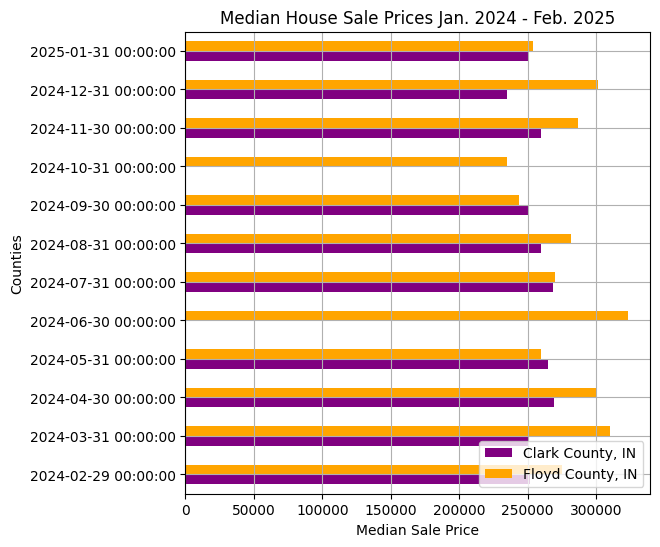

In [300]:
# Pivot the data to have 'Product' as columns and 'Segment' as the index
pivot_df =filtered_cf.pivot(index='Period End',
                    columns='Region',
                    values='Median Sale Price')

# Create a grouped barplot
colors = ['purple', 'orange']
ax = pivot_df.plot.barh(grid=True,
                       color=colors,
                       figsize=(6,6))

# Add legend
plt.legend(loc='lower right')

#Add title and label
ax.set_xlabel('Median Sale Price')
ax.set_ylabel('Counties')
ax.set_title('Median House Sale Prices Jan. 2024 - Feb. 2025')

plt.show()

With the exception of September 2024, Floyd County has a median sale price higher than Clark County. 

Note: It looks like I'm missing data for Clark County for June 2024 and October 2024. There were no NaN values in the data so I assume the data never existed for that time period. 

In [301]:
#display avg. price per square foot df for reference while plotting
average_ppsf

,Median Ppsf
Region,
"Clark County, IN",163.120663
"Floyd County, IN",151.948779


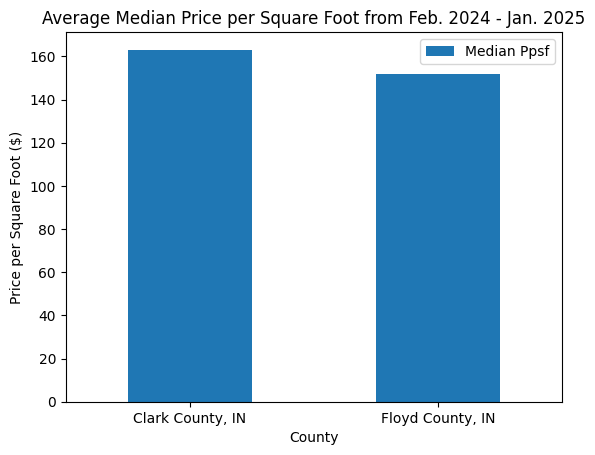

In [302]:
#bar chart showing average Median Ppsf for 
ax = average_ppsf.plot.bar(use_index=True, 
                           y='Median Ppsf', 
                           rot=0, 
                           xlabel='County', 
                           ylabel='Price per Square Foot ($)', 
                           title="Average Median Price per Square Foot from Feb. 2024 - Jan. 2025"
                           )

In [303]:
#display avg. sale price df for reference while plotting
average_saleprice

,Median Sale Price
Region,
"Clark County, IN",255938.5
"Floyd County, IN",278450.0


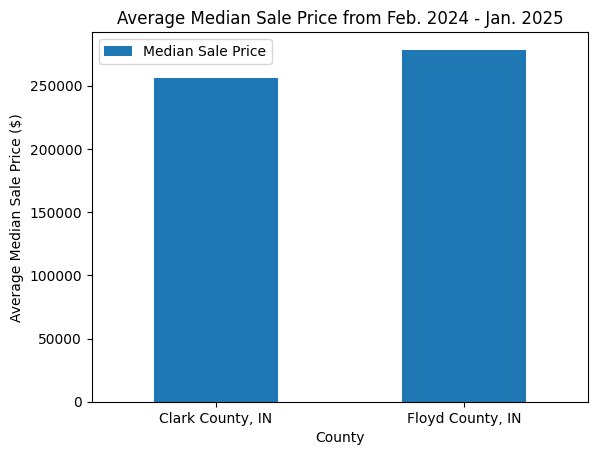

In [304]:
# average Median Ppsf for 
ax1 = average_saleprice.plot.bar(use_index=True, 
                                 y='Median Sale Price', 
                                 rot=0, 
                                 xlabel='County', 
                                 ylabel='Average Median Sale Price ($)', 
                                 title="Average Median Sale Price from Feb. 2024 - Jan. 2025"
                                 )

In [305]:
#displaying dataframe to assist with visualization
merged_ilearnG3df

,Corp ID,Corporation Name,ELA Proficient %,Math Proficient %,Science Proficient %
0,0935,Borden-Henryville School Corporation,30.9%,49.1%,49.6%
1,0945,Silver Creek School Corporation,41.7%,54.8%,41.5%
2,1000,Clarksville Community School Corp,13.7%,25.1%,20.6%
3,1010,Greater Clark County Schools,35.3%,47.1%,37.6%
4,2400,New Albany-Floyd Co Con Sch,55.8%,71.1%,49.1%


All of the datatypes in this (with the exception of the first column 'Corp ID') are objects. I need numeric data to visually plot this data. I will remove the percentages and turn the proficiency scores into floats. 

In [306]:
# making a copy of the merged ILEARN graph, to avoid writing over the original df
ilearn_copy = merged_ilearnG3df.copy()

#changing objects to floats
ilearn_copy['ELA Proficient %'] = ilearn_copy['ELA Proficient %'].str.rstrip('%').astype('float') / 100.0

#display the result
ilearn_copy

,Corp ID,Corporation Name,ELA Proficient %,Math Proficient %,Science Proficient %
0,0935,Borden-Henryville School Corporation,0.309,49.1%,49.6%
1,0945,Silver Creek School Corporation,0.417,54.8%,41.5%
2,1000,Clarksville Community School Corp,0.137,25.1%,20.6%
3,1010,Greater Clark County Schools,0.353,47.1%,37.6%
4,2400,New Albany-Floyd Co Con Sch,0.558,71.1%,49.1%


In [307]:
#changing objects to floats
ilearn_copy['Math Proficient %'] = ilearn_copy['Math Proficient %'].str.rstrip('%').astype('float') / 100.0

#display the result
ilearn_copy

,Corp ID,Corporation Name,ELA Proficient %,Math Proficient %,Science Proficient %
0,0935,Borden-Henryville School Corporation,0.309,0.491,49.6%
1,0945,Silver Creek School Corporation,0.417,0.548,41.5%
2,1000,Clarksville Community School Corp,0.137,0.251,20.6%
3,1010,Greater Clark County Schools,0.353,0.471,37.6%
4,2400,New Albany-Floyd Co Con Sch,0.558,0.711,49.1%


In [308]:
#changing objects to floats
ilearn_copy['Science Proficient %'] = ilearn_copy['Science Proficient %'].str.rstrip('%').astype('float') / 100.0

#display the result
ilearn_copy

,Corp ID,Corporation Name,ELA Proficient %,Math Proficient %,Science Proficient %
0,0935,Borden-Henryville School Corporation,0.309,0.491,0.496
1,0945,Silver Creek School Corporation,0.417,0.548,0.415
2,1000,Clarksville Community School Corp,0.137,0.251,0.206
3,1010,Greater Clark County Schools,0.353,0.471,0.376
4,2400,New Albany-Floyd Co Con Sch,0.558,0.711,0.491


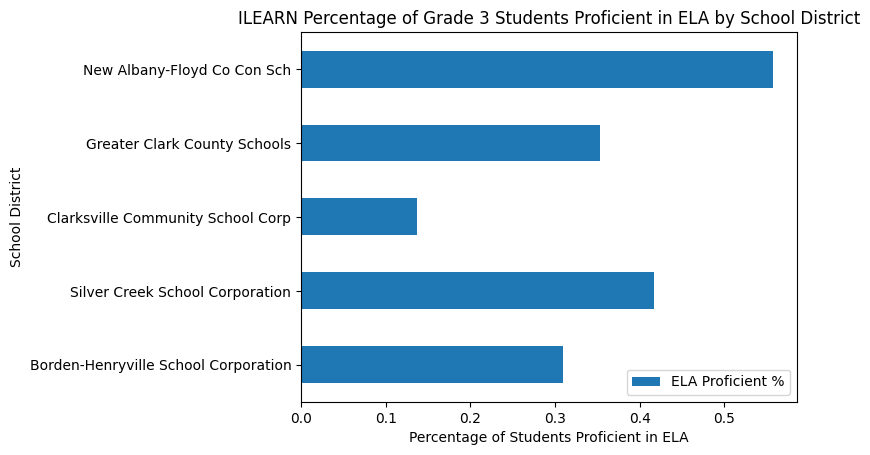

In [309]:
#bar chart to plot % of students proficient in ELA by School District
ax2 = ilearn_copy.plot.barh(x='Corporation Name', 
                                 y='ELA Proficient %', 
                                 rot=0, 
                                 xlabel='Percentage of Students Proficient in ELA', 
                                 ylabel='School District', 
                                 title="ILEARN Percentage of Grade 3 Students Proficient in ELA by School District") 


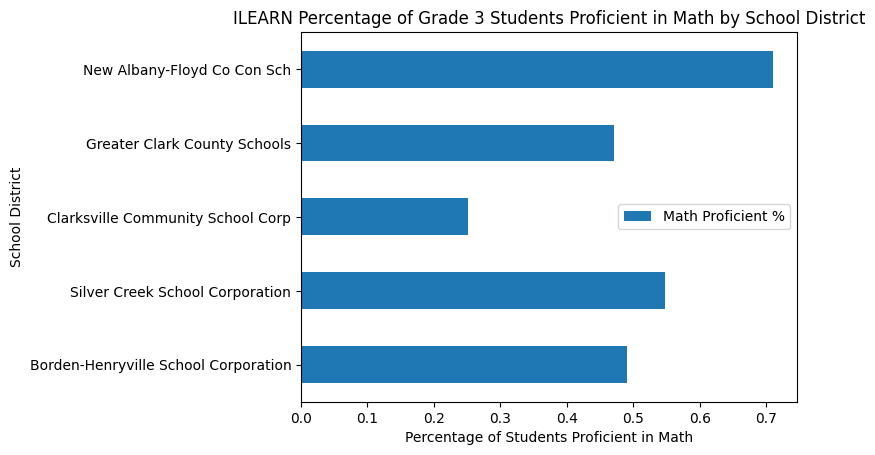

In [310]:
#bar chart to plot % of students proficient in ELA by School District
ax2 = ilearn_copy.plot.barh(x='Corporation Name', 
                                 y='Math Proficient %', 
                                 rot=0, 
                                 xlabel='Percentage of Students Proficient in Math', 
                                 ylabel='School District', 
                                 title="ILEARN Percentage of Grade 3 Students Proficient in Math by School District")

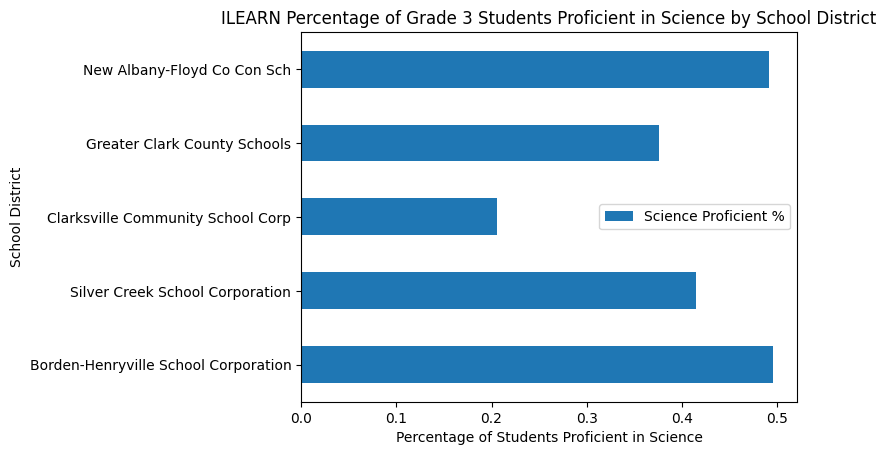

In [311]:
#bar chart to plot % of students proficient in ELA by School District
ax3 = ilearn_copy.plot.barh(x='Corporation Name', 
                                 y='Science Proficient %', 
                                 rot=0, 
                                 xlabel='Percentage of Students Proficient in Science', 
                                 ylabel='School District', 
                                 title="ILEARN Percentage of Grade 3 Students Proficient in Science by School District")

In [312]:
#display Social Studies Proficiency df for reference while plotting
soc_copy3

,Corp ID,Corp Name,Social Studies Proficient %
24,0935,Borden-Henryville School Corporation,26.4%
25,0945,Silver Creek School Corporation,29.3%
26,1000,Clarksville Community School Corp,14.6%
27,1010,Greater Clark County Schools,28.4%
64,2400,New Albany-Floyd Co Con Sch,40.1%


In [318]:
# change objects to floats
soc_copy4 = soc_copy3.copy()
soc_copy4['Social Studies Proficient %'] =soc_copy4 ['Social Studies Proficient %'].str.rstrip('%').astype('float') / 100.0


#display result
soc_copy4

,Corp ID,Corp Name,Social Studies Proficient %
24,0935,Borden-Henryville School Corporation,0.264
25,0945,Silver Creek School Corporation,0.293
26,1000,Clarksville Community School Corp,0.146
27,1010,Greater Clark County Schools,0.284
64,2400,New Albany-Floyd Co Con Sch,0.401


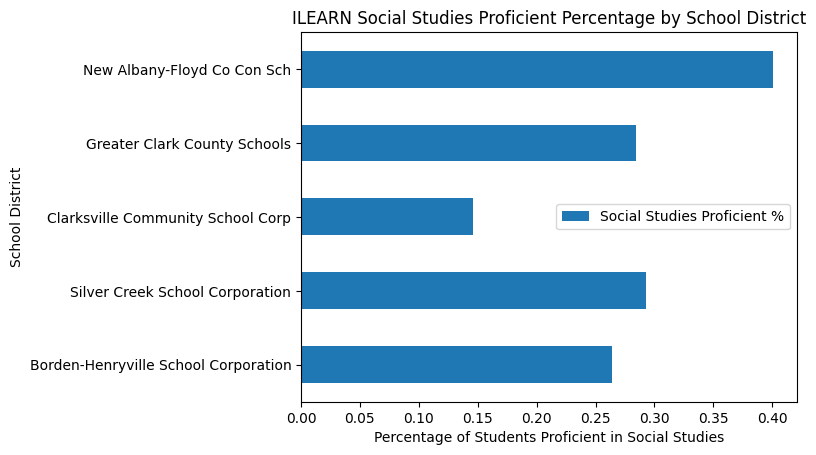

In [319]:
#bar chart to plot % of students proficient in ELA by School District
ax4 = soc_copy4.plot.barh(x='Corp Name', 
                         y='Social Studies Proficient %', 
                         rot=0, 
                         xlabel='Percentage of Students Proficient in Social Studies', 
                         ylabel='School District', 
                         title="ILEARN Social Studies Proficient Percentage by School District"
                         )

# Final Analysis

Floyd county has higher 